# Clase Nº 8: Aprendizaje No Supervisado
## Agrupación de datos sin etiquetas (Clustering)
-----
## Objetivo: identificar cuántos segmentos latentes de clientes existen a partir de sus comportamientos de compra y uso del sitio, sin etiquetas previas..
-----

### Flujo de Trabajo:
1. Importación de librerías

2. Carga del dataset original   

3. Gráficos de distribución previa

4. Escalado y estandarización de los datos

5. Método del Codo

6. Entrenamiento del modelo definitivo seleccionando k_optimo = 4 y guardando la columna

7. El gráfico de dispersión final (Scatter Plot) cruzando frecuencia mensual vs ticket en dólares, pintado por clusters.

## 1. Importación de libreria.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

## 2. Carga de datos

In [18]:
data = pd.read_csv('dataset_segmentacion_clientes.csv')

# Análisis Exploratorio de Datos (EDA)

Exploración inicial

In [19]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   purchase_freq_month   700 non-null    float64
 1   avg_basket_usd        700 non-null    float64
 2   time_on_site_min      700 non-null    float64
 3   discount_sensitivity  700 non-null    float64
 4   returns_rate          700 non-null    float64
 5   noise_gauss           700 non-null    float64
 6   noise_uniform         700 non-null    float64
dtypes: float64(7)
memory usage: 38.4 KB


In [20]:
print("\n--- Estadísticas Descriptivas ---")
data.describe()


--- Estadísticas Descriptivas ---


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,5.875724,248.173491,16.784799,0.425083,0.337194,0.023814,-0.010523
std,4.471079,154.904372,12.914111,0.431467,0.356623,1.009325,1.679810
min,0.100000,86.994100,3.163206,0.000000,0.000000,-3.566175,-2.993585
25%,2.278418,90.766945,6.603950,0.000000,0.000000,-0.654168,-1.424864
50%,4.134580,180.223799,9.974407,0.296475,0.165559,0.076845,0.013148
75%,11.214919,449.719033,34.341360,1.000000,0.800000,0.728304,1.407124
max,14.603388,452.973583,38.348156,1.000000,0.800000,2.863317,2.995020


ANALISIS: Diferencia crítica de escalas, avg_basket_usd se extiende hasta más de 450, mientras que discount_sensitivity o returns_rate están acotadas entre 0 y 1.

## 3. Visualización previa para observar cómo se distribuyen las variables originales

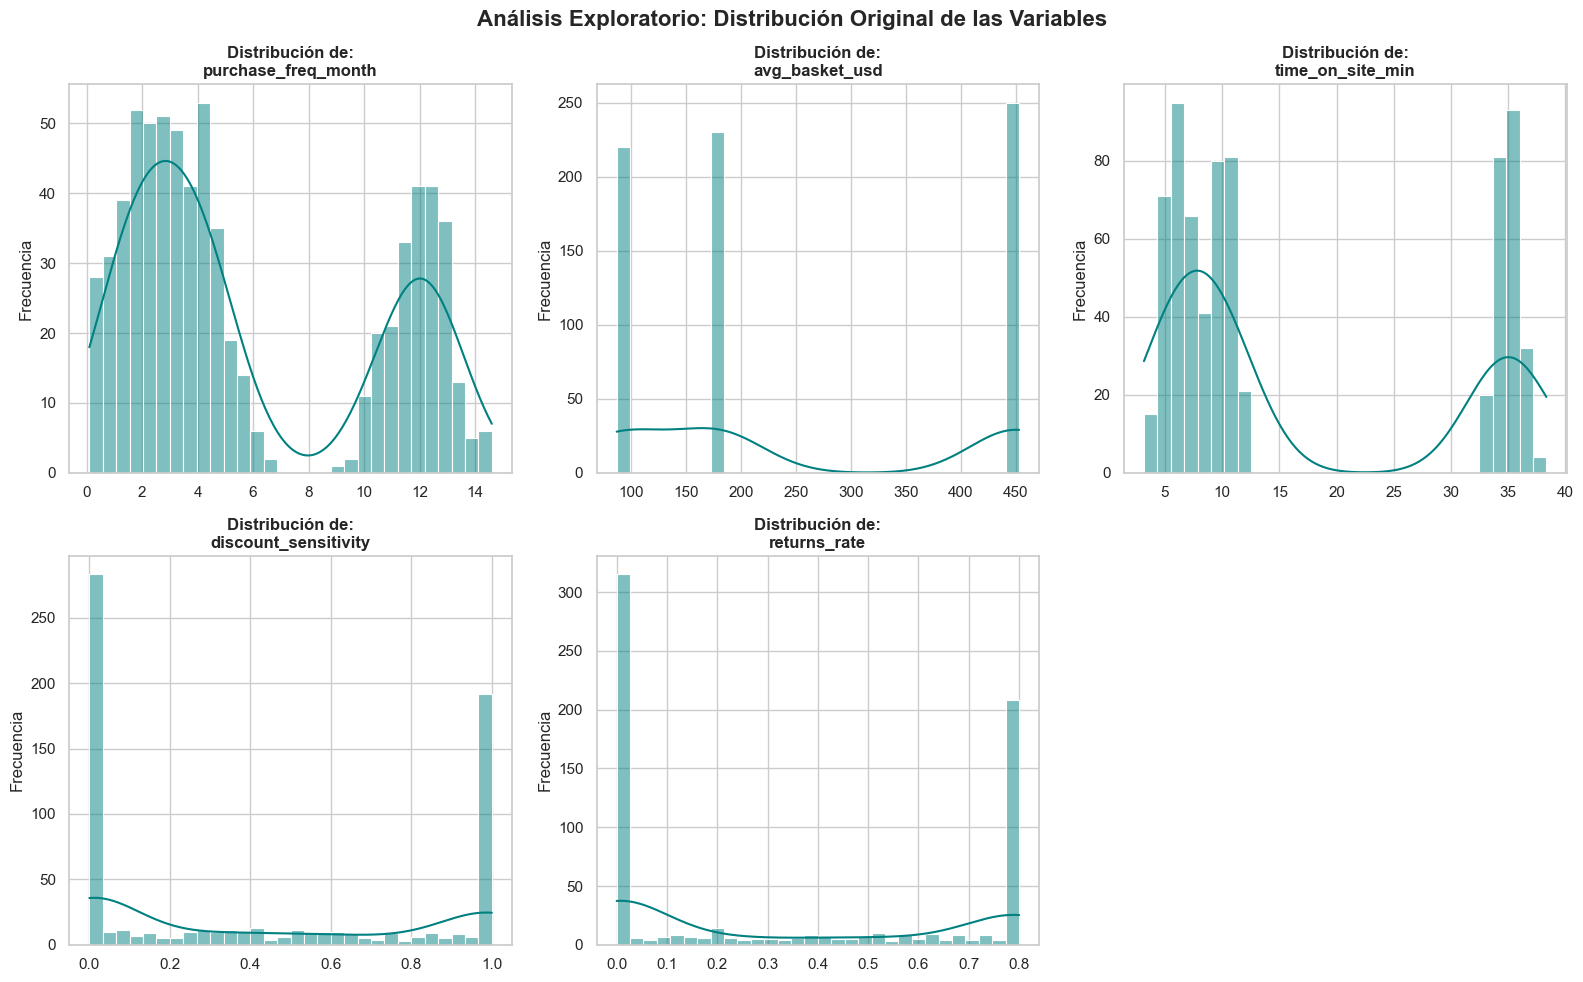

In [25]:
# VARIABLES A TRABAJAR
mis_variables = ['purchase_freq_month', 'avg_basket_usd', 'time_on_site_min', 'discount_sensitivity', 'returns_rate']

# GRAFICOS DE DISTRIBUCIÓN
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()  # Aplanar la matriz de ejes

for i, col in enumerate(mis_variables):
    sns.histplot(data=data, x=col, kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribución de:\n{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

fig.delaxes(axes[-1])

plt.suptitle('Análisis Exploratorio: Distribución Original de las Variables', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 4.Normalización para las columnas necesaeias

In [26]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(data[mis_variables])

df_scaled_check = pd.DataFrame(X_scaled, columns=mis_variables)
print("--- Muestra de los datos escalados (Media ~ 0, Desviación ~ 1) ---")
display(df_scaled_check.head())

--- Muestra de los datos escalados (Media ~ 0, Desviación ~ 1) ---


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
0,1.181048,-0.432012,1.300224,1.333423,1.298671
1,1.382696,-0.449219,1.444979,0.834706,-0.946196
2,-0.822026,1.305039,-0.755841,1.097540,-0.946196
3,-0.367604,-1.028253,-0.461093,-0.985910,1.298671
4,-0.930849,1.302382,-0.738500,-0.985910,-0.936996


Evaluación de K mediante el Método del Codo (Elbow Method)
Iteramos entre 2 y 6 clusters calculando la inercia

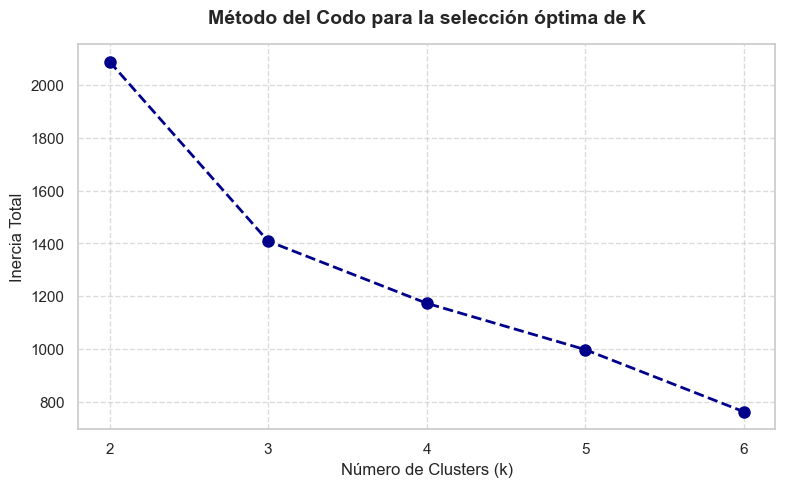

Clusters (k) = 2 -> Inercia = 2088.88
Clusters (k) = 3 -> Inercia = 1408.70
Clusters (k) = 4 -> Inercia = 1173.44
Clusters (k) = 5 -> Inercia = 997.74
Clusters (k) = 6 -> Inercia = 762.47


In [28]:
inercia = []
k_valores = range(2, 7)

for k in k_valores:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

# GRAFICO PARA EL MÉTODO DEL CODO
plt.figure(figsize=(9, 5))
plt.plot(k_valores, inercia, 'o--', color='darkblue', linewidth=2, markersize=8)
plt.title('Método del Codo para la selección óptima de K', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Inercia Total', fontsize=12)  # Cambiado el eje también para coherencia
plt.xticks(k_valores)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

for k, i_val in zip(k_valores, inercia):
    print(f"Clusters (k) = {k} -> Inercia = {i_val:.2f}")

ANALISIS: k = 4 mediante el método del codo, es optimo ya que representa el punto de inflexión donde la inercia disminuye de manera balanceada y permite mapear con precisión los cuatro comportamientos diferenciados en la consigna.

## 5. Entrenamiento del modelo final asignando el codo en k=4. 

In [30]:
k_optimo = 4

kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)

data['cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"¡Modelo entrenado con éxito usando k={k_optimo}!")
print("\nCantidad de clientes asignados a cada segmento:")
print(data['cluster'].value_counts().sort_index())

¡Modelo entrenado con éxito usando k=4!

Cantidad de clientes asignados a cada segmento:
cluster
0    230
1    121
2    220
3    129
Name: count, dtype: int64


Perfilado de segmentos mediante Centroides en Escala Original
Para realizar la interpretación de negocio, calculamos las medias de mis_variables agrupando por la nueva etiqueta del cluster.

In [34]:
centroides = data.groupby('cluster')[mis_variables].mean()

print("--- CENTROIDES EN ESCALA ORIGINAL ---")
display(centroides.round(2))



--- CENTROIDES EN ESCALA ORIGINAL ---


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
cluster,,,,,
0,11.96,180.00,35.02,0.54,0.33
1,1.80,450.03,6.07,0.36,0.73
2,4.09,89.96,10.00,0.38,0.30
3,1.89,450.21,5.89,0.36,0.04


### ANALISIS DE CADA CLUSTERS: 

Cluster 0- Compradores Recurrentes de Alta Permanencia en el sitio, es el grupo con mayor frecuencia mensual de compra más alta aproximado de 11.96 y el mayor tiempo de permanencia en el sitio de al rededor de 35.02 minutos. Con ticket promedio es intermedio $180 USD, su sensibilidad a descuentos es moderada-alta y su tasa de devoluciones es normal aprox 0.33.
Son usuarios muy activos. 

Cluster 1- Tienen una frecuencia de compra muy baja 1.85 y navegan menos. Compran productos caros, pero tienen la tasa de devolución más alta del 0.73.
comprador de Ofertas de Altas Devoluciones.

Cluster 2- Compran unas 4 veces al mes y navegan unos 10 minutos, pero tienen el ticket promedio más bajo de todos $89.96. Su tasa de devolución es moderada 0.30.

Cluster 3- Al igual que el Cluster 1, compran de forma esporádica ocacional y pasan poco tiempo en la web 5.97 minutos, compran productos altos y suTicket máximo de aproximadamente de $450.12, ventaja es que casi no devuelven y tienen baja sensibilidad a los descuentos.

## 6. Mapa de calor

Para hacer el perfil de los clientes, cruzando los clusters que descubrió el algoritmo.

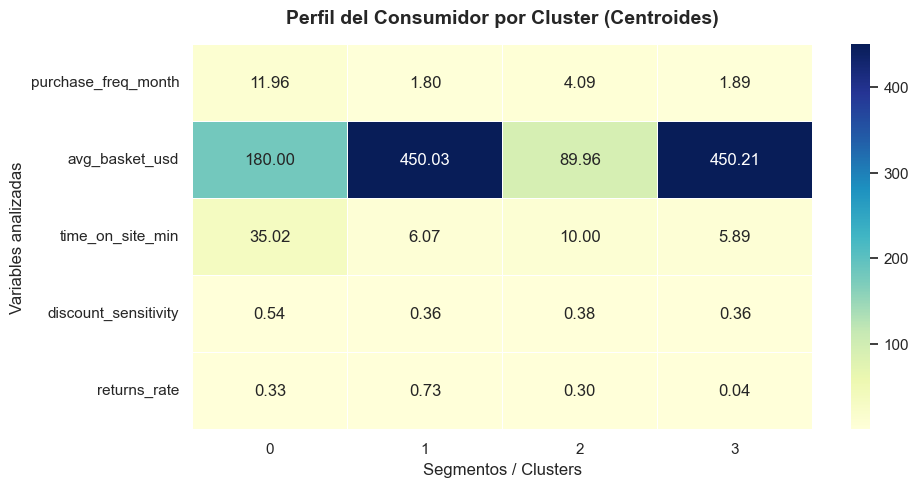

In [35]:
plt.figure(figsize=(10, 5))
sns.heatmap(centroides.T, annot=True, fmt=".2f", cmap="YlGnBu", cbar=True, linewidths=0.5)
plt.title('Perfil del Consumidor por Cluster (Centroides)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Segmentos / Clusters', fontsize=12)
plt.ylabel('Variables analizadas', fontsize=12)
plt.show()

Patrons a buscar:
1. Grupos con frecuencia alta pero ticket bajo y alta sensibilidad a descuentos. 
Respuesa: ningún grupo cumple exactamente con las tres condiciones juntas, sino que el comportamiento se comparte entre el Cluster 0 y el Cluster 2.

2. Grupos con frecuencia baja pero ticket alto y baja sensibilidad (compras esporádicas pero grandes).
Respuesta: el Cluster 1 y el Cluster 3 comparten de manera idéntica los patrones de Frecuencia y Ticket Promedio: grupo 1 tienen una frecuencia baja,pero grupo 3 tiene un ticket promedio alto de 450.21

3. Grupos con tiempo en sitio y tasa de devoluciones diferenciado
Respuesta: cluster 0 explora mucho y tiene devolución baja-moderado. cluster 3 explora poco y devuelve poco.

## 7. Visualización de Relaciones Críticas (Scatter Plot)
Evaluamos cómo interactúan dos de las variables con más peso (purchase_freq_month y avg_basket_usd) según el segmento que descubrió K-Means

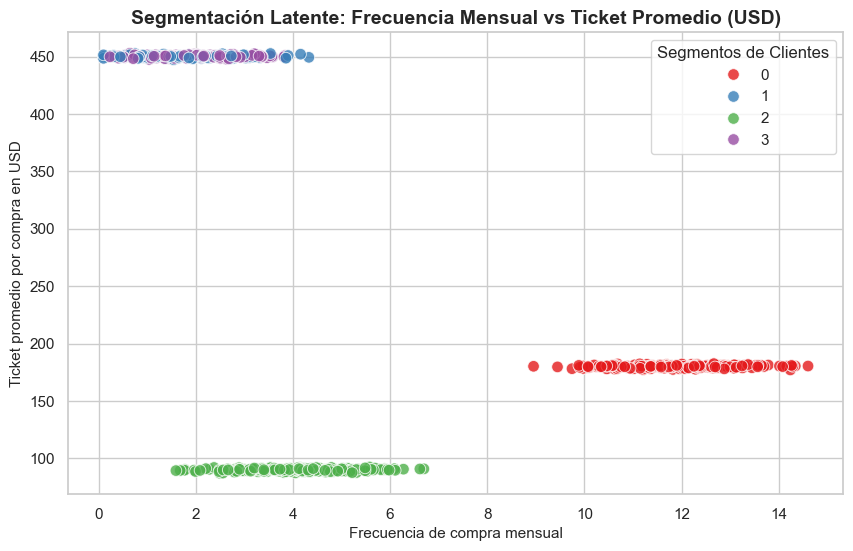

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data, 
    x='purchase_freq_month', 
    y='avg_basket_usd', 
    hue='cluster', 
    palette='Set1', 
    s=70, 
    alpha=0.8,
    edgecolor='w'
)

plt.title('Segmentación Latente: Frecuencia Mensual vs Ticket Promedio (USD)', fontsize=14, fontweight='bold')
plt.xlabel('Frecuencia de compra mensual', fontsize=11)
plt.ylabel('Ticket promedio por compra en USD', fontsize=11)
plt.legend(title='Segmentos de Clientes', loc='best')
plt.show()